In [3]:
# Cell No: 1
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing import image

import numpy as np
import matplotlib.pyplot as plt
import cv2

img_path = "/content/drive/MyDrive/4-2/Deep Learning/Assignments/Assignment-3/dataset/face/anan.png"

(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

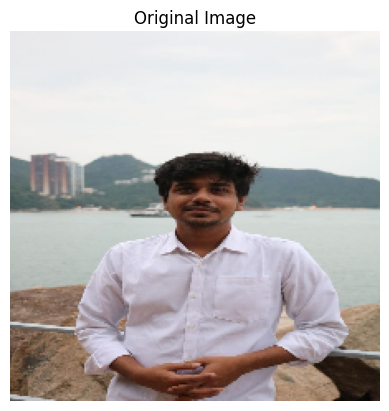

In [4]:
# Cell No: 3
def load_and_preprocess(img_path, target_size=(224, 224)):
    img = image.load_img(img_path, target_size=target_size)
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = preprocess_input(img_array)
    return img, img_array

original_img, processed_img = load_and_preprocess(img_path)

plt.imshow(original_img)
plt.title("Original Image")
plt.axis('off')

In [5]:
# Cell No: 4
def load_model():
    base_model = VGG16(weights='imagenet', include_top=False)
    return base_model

model = load_model()
model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, None, None, 3)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, None, None, 64) │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, None, None, 64) │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, None, None, 64) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, None, None,     │        73,856 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, None, None,     │       147,584 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, None, None,     │             0 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, None, None,     │       295,168 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, None, None,     │       590,080 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, None, None,     │       590,080 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, None, None,     │             0 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, None, None,     │     1,180,160 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, None, None,     │             0 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │             

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
# Cell No: 5
def create_feature_extractor(model):
    layer_names = [
        'block1_conv1',  # Early
        'block3_conv1',  # Middle
        'block5_conv1'   # Deep
    ]

    outputs = [model.get_layer(name).output for name in layer_names]
    feature_model = Model(inputs=model.input, outputs=outputs)

    return feature_model, layer_names

feature_model, layer_names = create_feature_extractor(model)

In [7]:
# Cell No: 6
def get_feature_maps(feature_model, processed_img):
    feature_maps = feature_model.predict(processed_img)
    return feature_maps

feature_maps = get_feature_maps(feature_model, processed_img)

for name, fmap in zip(layer_names, feature_maps):
    print(f"{name} shape: {fmap.shape}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 824ms/step
block1_conv1 shape: (1, 224, 224, 64)
block3_conv1 shape: (1, 56, 56, 256)
block5_conv1 shape: (1, 14, 14, 512)


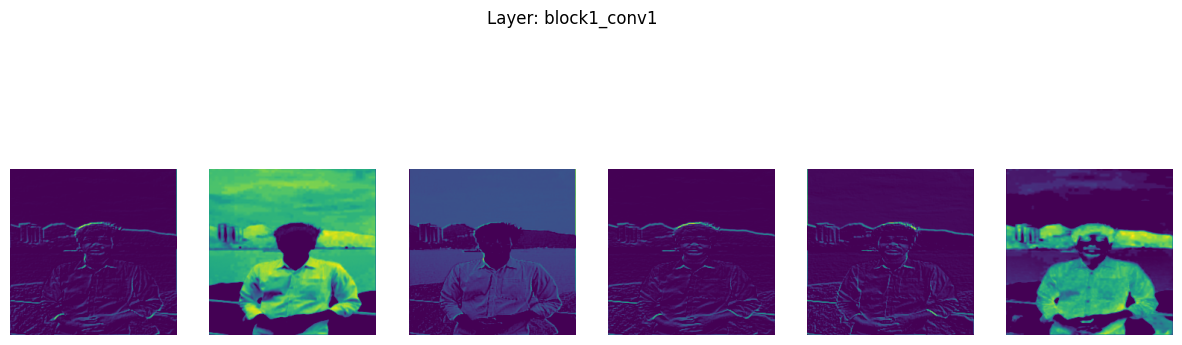

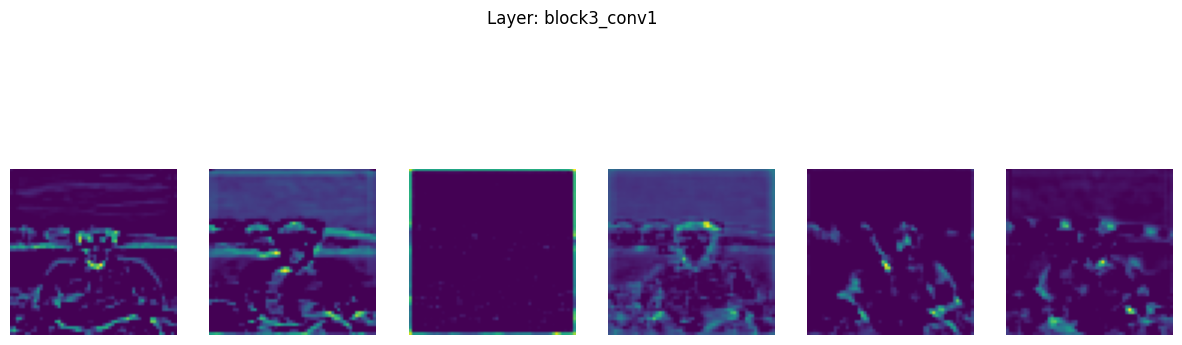

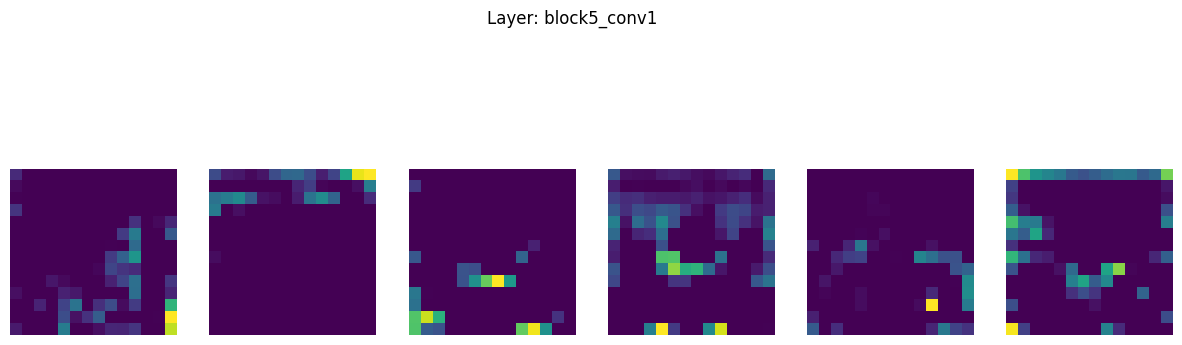

In [10]:
# Cell No: 7
def visualize_feature_maps(feature_maps, layer_names, max_filters=6):
    for fmap, layer_name in zip(feature_maps, layer_names):
        num_filters = min(max_filters, fmap.shape[-1])

        plt.figure(figsize=(15, 5))
        plt.suptitle(f"Layer: {layer_name}")

        for i in range(num_filters):
            plt.subplot(1, num_filters, i+1)
            plt.imshow(fmap[0, :, :, i], cmap='viridis')
            plt.axis('off')

        plt.savefig("/content/drive/MyDrive/4-2/Deep Learning/Assignments/Assignment-3/results/feature_extraction.png")

visualize_feature_maps(feature_maps, layer_names)